# Wave Data Plots — Marconi Beach, Cape Cod

**Author:** Chelsea Volpano  
**Email:** cvolpano@contractor.usgs.gov | cvolpano@gmail.com  
**Date:** 2026-06-24  
**Created using Claude Sonnet 4.6**

---

Generates figures from the downloaded wave CSVs:
1. **Station map** — locations of WIS ST63064, NDBC 44020, and Marconi Beach
2. **Time series** — Hs, Tp, wave power, and water depth with 7-day rolling mean
3. **Monthly box plots** — seasonal distribution of Hs, Tp, wave power
4. **Hs–Tp scatter** — coloured by wave power with iso-power contours

Data sources:
- **WIS ST63064** — Oct–Dec 2024 (hindcast, 123 m depth)
- **NDBC 44020** — Oct 2024–Mar 2025 (observed, 16.5 m depth)
- **In-situ instrument** — Dec 2024–Mar 2025 (Marconi Beach)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

%matplotlib inline

In [45]:
# ── Configuration ─────────────────────────────────────────────────────────────
OUT_DIR  = Path("wave_data")
PLOT_DIR = Path("wave_plots")
PLOT_DIR.mkdir(exist_ok=True)

WIS_FILE    = OUT_DIR / "WIS_ST63064_2024-10_to_2024-12.csv"
NDBC_FILE1  = OUT_DIR / "NDBC_44020_2024-10_to_2025-03.csv"
NDBC_FILE2  = OUT_DIR / "NDBC_44013_2024-10_to_2025-03.csv"
NDBC_FILE3  = OUT_DIR / "NDBC_44008_2024-10_to_2025-03.csv"
# WIS_FILE    = OUT_DIR / "WIS_ST63064_2006-01_to_2026-01.csv"
# NDBC_FILE1  = OUT_DIR / "NDBC_44020_2006-01_to_2026-01.csv"
# NDBC_FILE2  = OUT_DIR / "NDBC_44013_2006-01_to_2026-01.csv"
# NDBC_FILE3  = OUT_DIR / "NDBC_44008_2006-01_to_2026-01.csv"

INSITU_FILE = Path("sig1000_waves_ALL.csv")   # update path as needed

# START = "2006-01-01"
# END   = "2026-01-31"
START = "2024-10-01"
END = "2025-03-06"

# Field survey dates
SURVEY_DATES = ["2024-10-23", "2025-01-23", "2025-03-06"]

# In-situ wave data deployment period
INSITU_START = "2024-12-10"
INSITU_END   = "2025-03-06"

# Wave power:  P = (rho * g^2) / (64 * pi) * Hs^2 * Tp  [kW/m]
RHO     = 1025.0
G       = 9.81
P_CONST = (RHO * G**2) / (64 * np.pi) / 1000

# Spectral colormap palette
_sp = plt.colormaps["plasma"]
PALETTE = {
    "ndbc1":      _sp(0.85),   # blue
    "ndbc_mean1": _sp(0.80),   # darker blue
    "ndbc2":      _sp(0.79),
    "ndbc_mean2":  _sp(0.7),
    "ndbc3":      _sp(0.59),
    "ndbc_mean3":  _sp(0.5),
    "wis":        _sp(0.00),   # red
    "wis_mean":  _sp(0.09),   # dark red
    "insitu":    _sp(0.2),   # golden orange
    "insitu_mean": _sp(0.25), # darker orange
    "survey":    "black",   # green
    "depth":     _sp(0.10),   # purple-ish for water depth
}

## 1. Load Data

In [46]:
def load_ndbc(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["WVHT", "DPD"]].rename(columns={"WVHT": "Hs", "DPD": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Hs"] = df["Hs"].where(df["Hs"] < 99.0)
    df["Tp"] = df["Tp"].where(df["Tp"] < 99.0)
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    return df

def load_wis(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["waveHs", "waveTp"]].rename(columns={"waveHs": "Hs", "waveTp": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    return df

def load_insitu(path):
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.rename(columns={
        "time":        "datetime",
        "wh_4061":     "Hs",
        "wp_peak":     "Tp",
        "water_depth": "depth",
        "water_level": "water_level",
    })
    df = df.set_index("datetime")
    df = df.apply(pd.to_numeric, errors="coerce")
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    return df

ndbc1 = load_ndbc(NDBC_FILE1)
print(f"NDBC 44020 loaded:  {len(ndbc1)} rows, {ndbc1.index.min()} → {ndbc1.index.max()}")
ndbc2 = load_ndbc(NDBC_FILE2)
print(f"NDBC 44013 loaded:  {len(ndbc2)} rows, {ndbc2.index.min()} → {ndbc2.index.max()}")
ndbc3 = load_ndbc(NDBC_FILE3)
print(f"NDBC 44008 loaded:  {len(ndbc3)} rows, {ndbc3.index.min()} → {ndbc3.index.max()}")

if WIS_FILE.exists():
    wis = load_wis(WIS_FILE)
    print(f"WIS ST63064 loaded: {len(wis)} rows, {wis.index.min()} → {wis.index.max()}")
else:
    wis = None
    print("WIS file not found — plotting NDBC only.")

if INSITU_FILE.exists():
    insitu = load_insitu(INSITU_FILE)
    print(f"In-situ loaded:     {len(insitu)} rows, {insitu.index.min()} → {insitu.index.max()}")
else:
    insitu = None
    print("In-situ file not found — skipping.")


NDBC 44020 loaded:  26208 rows, 2024-10-01 00:00:00 → 2025-03-31 23:50:00
NDBC 44013 loaded:  26208 rows, 2024-10-01 00:00:00 → 2025-03-31 23:50:00
NDBC 44008 loaded:  2506 rows, 2024-10-01 00:00:00 → 2024-10-18 09:30:00
WIS ST63064 loaded: 2205 rows, 2024-10-01 01:00:00 → 2024-12-31 23:00:00
In-situ loaded:     2182 rows, 2024-12-09 18:00:00 → 2025-03-10 15:00:00


In [47]:
# ── Shared plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.spines.top":   True,
    "axes.spines.right": True,
    "axes.grid":         True,
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.6,
    "grid.linestyle":    "--",
    "axes.labelsize":    11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.dpi":        150,
})

date_fmt = mdates.DateFormatter("%b '%y")
date_loc = mdates.MonthLocator()

def style_xaxis(ax, start, end):
    span_days = (pd.Timestamp(end) - pd.Timestamp(start)).days
    if span_days <= 180:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    elif span_days <= 730:
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    else:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)

def rolling(s, days=7):
    return s.rolling(f"{days}D", center=True, min_periods=24).mean()

def add_survey_lines(ax, dates):
    for i, d in enumerate(dates):
        ax.axvline(pd.Timestamp(d), color=PALETTE["survey"],
                   lw=1.2, ls="--", zorder=3)

def add_insitu_bar(ax, start, end, plot_start, plot_end):
    t0 = max(pd.Timestamp(start), pd.Timestamp(plot_start))
    t1 = min(pd.Timestamp(end),   pd.Timestamp(plot_end))
    if t0 >= t1:
        return
    ylim = ax.get_ylim()
    ypos = ylim[1] * 0.97
    ax.plot([t0, t1], [ypos, ypos], color=PALETTE["insitu"],
            lw=4, solid_capstyle="butt", zorder=4, clip_on=True)

## 2. Station Location Map

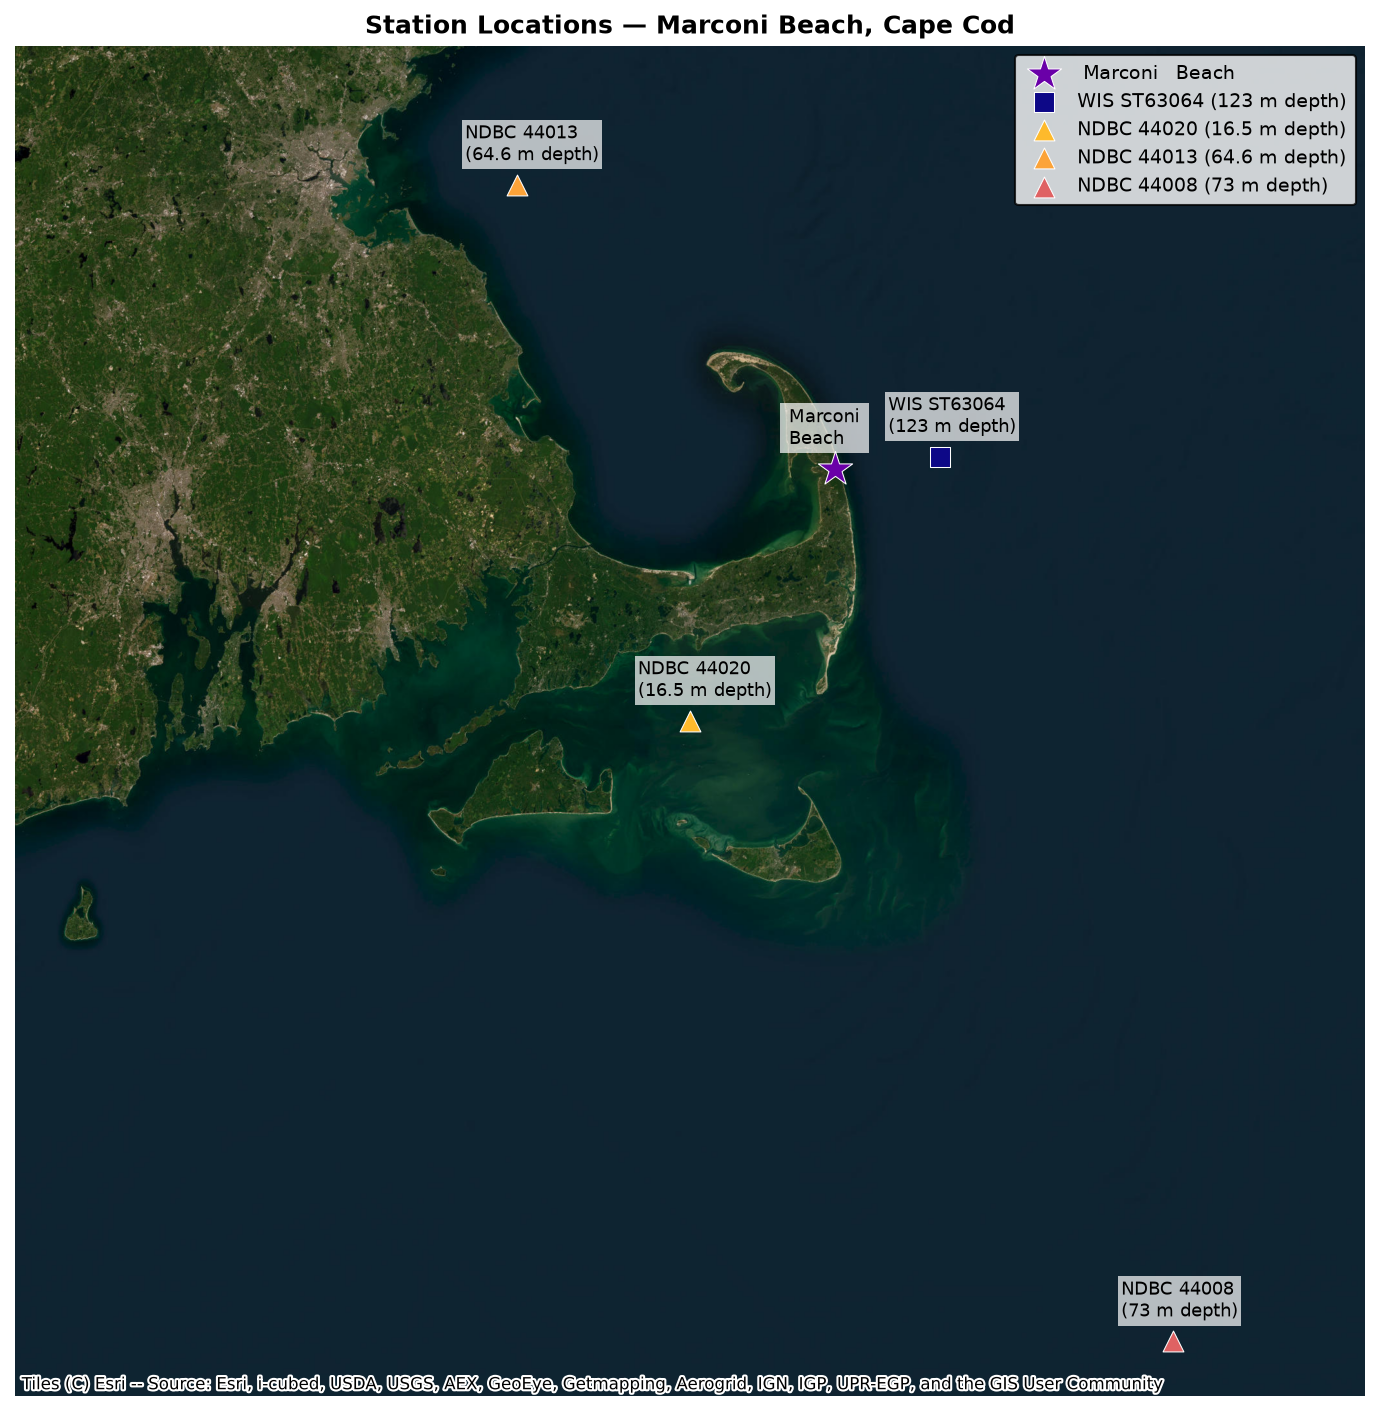

✓ Saved station_map.png


In [69]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

stations = {
    " Marconi \n Beach ": {"lon": -69.9741, "lat": 41.8977, "marker": "*", "color": PALETTE["insitu"], "edgecolor": "white", "linewidth": 0.5, "size": 300},
    "WIS ST63064\n(123 m depth)":  {"lon": -69.7500, "lat": 41.9167, "marker": "s", "color": PALETTE["wis"], "edgecolor": "white", "linewidth": 0.5, "size": 100},
    "NDBC 44020\n(16.5 m depth)":  {"lon": -70.283,  "lat": 41.497,  "marker": "^", "color": PALETTE["ndbc1"], "edgecolor": "white", "linewidth": 0.5, "size": 100},
    "NDBC 44013\n(64.6 m depth)":  {"lon": -70.651,  "lat": 42.346,  "marker": "^", "color": PALETTE["ndbc2"], "edgecolor": "white", "linewidth": 0.5, "size": 100},
    "NDBC 44008\n(73 m depth)":  {"lon": -69.254,  "lat": 40.500,  "marker": "^", "color": PALETTE["ndbc3"], "edgecolor": "white", "linewidth": 0.5, "size": 100},
}

gdf = gpd.GeoDataFrame(
    [{"name": k, **v} for k, v in stations.items()],
    geometry=[Point(v["lon"], v["lat"]) for v in stations.values()],
    crs="EPSG:4326"
).to_crs(epsg=3857)

cx, cy = gpd.GeoSeries([Point(-70.283, 41.497)], crs="EPSG:4326").to_crs(3857).iloc[0].coords[0]
half = 160000
xmin, xmax = cx - half, cx + half
ymin, ymax = cy - half, cy + half

fig_map = plt.figure(figsize=(9, 9))
ax_map  = fig_map.add_axes([0.0, 0.0, 1.0, 1.0])
ax_map.set_xlim(xmin, xmax)
ax_map.set_ylim(ymin, ymax)
ax_map.set_aspect("equal")
ax_map.set_axis_off()

ctx.add_basemap(ax_map, source=ctx.providers.Esri.WorldImagery, zoom=10, crs="EPSG:3857")


for _, row in gdf.iterrows():
    ax_map.scatter(row.geometry.x, row.geometry.y,
                   marker=row["marker"], color=row["color"], s=row["size"],
                   zorder=5, edgecolors="white", linewidths=0.5,
                   label=row["name"].replace("\n", " "))
    ax_map.annotate(row["name"],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(-25, 12), textcoords="offset points",
                    fontsize=8.5, zorder=6,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5))

ax_map.set_title("Station Locations — Marconi Beach, Cape Cod",
                 fontsize=12, fontweight="bold", pad=6)
handles, labels = ax_map.get_legend_handles_labels()
ax_map.legend(handles, labels, loc="upper right", fontsize=9, framealpha=0.8,frameon=True,edgecolor="black",borderpad=0.5)


fig_map.savefig(PLOT_DIR / "station_map.png", dpi=150, bbox_inches="tight", pad_inches=0.05)
plt.show()
print("✓ Saved station_map.png")

## 3. Time Series — Hs, Tp, Wave Power, Water Depth

Separate plots for NDBC 44020 and WIS ST63064, each with in-situ data overlaid.  
Green dashed lines = field surveys. Amber bar = in-situ deployment period.

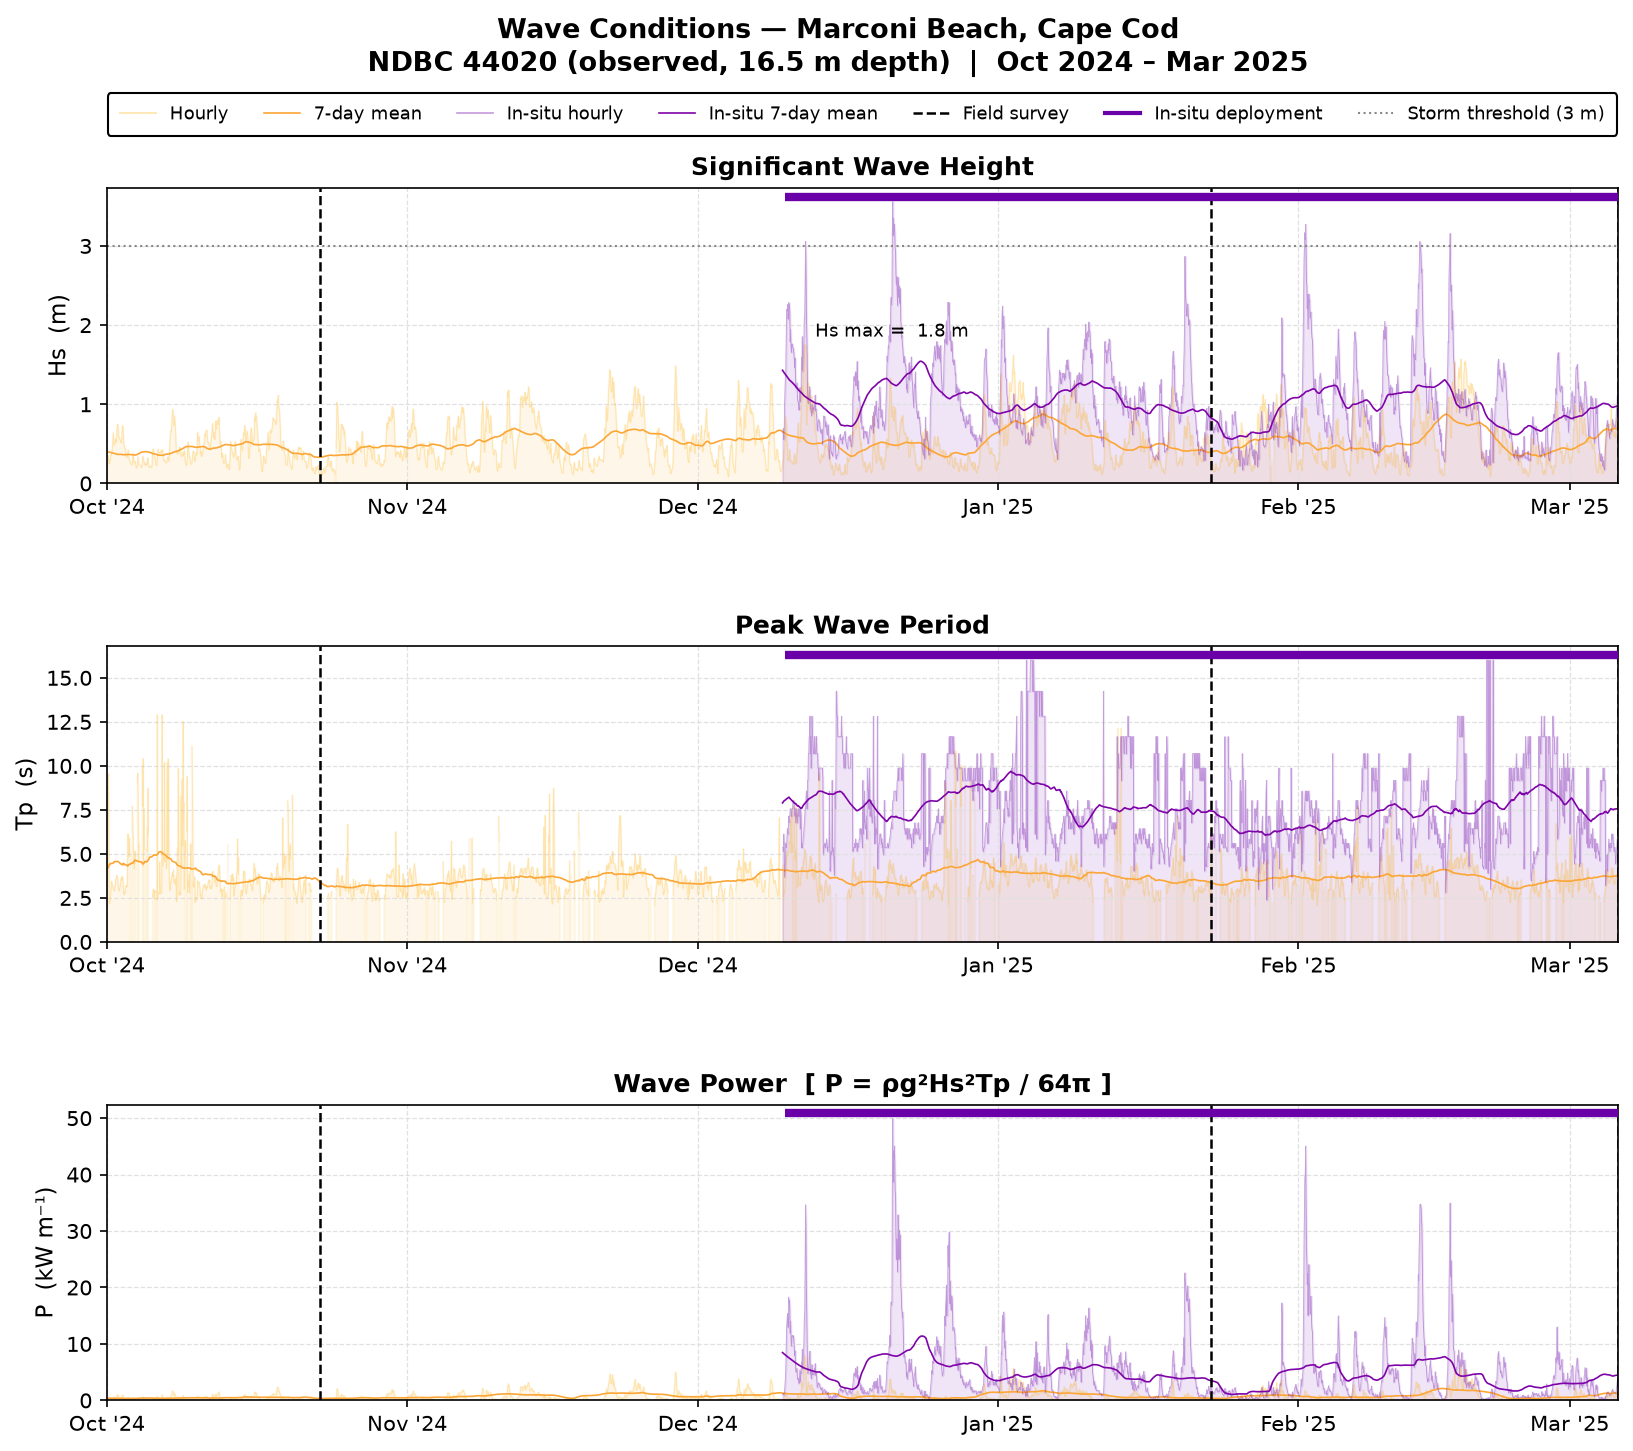

✓ Saved wave_timeseries_NDBC44020.png


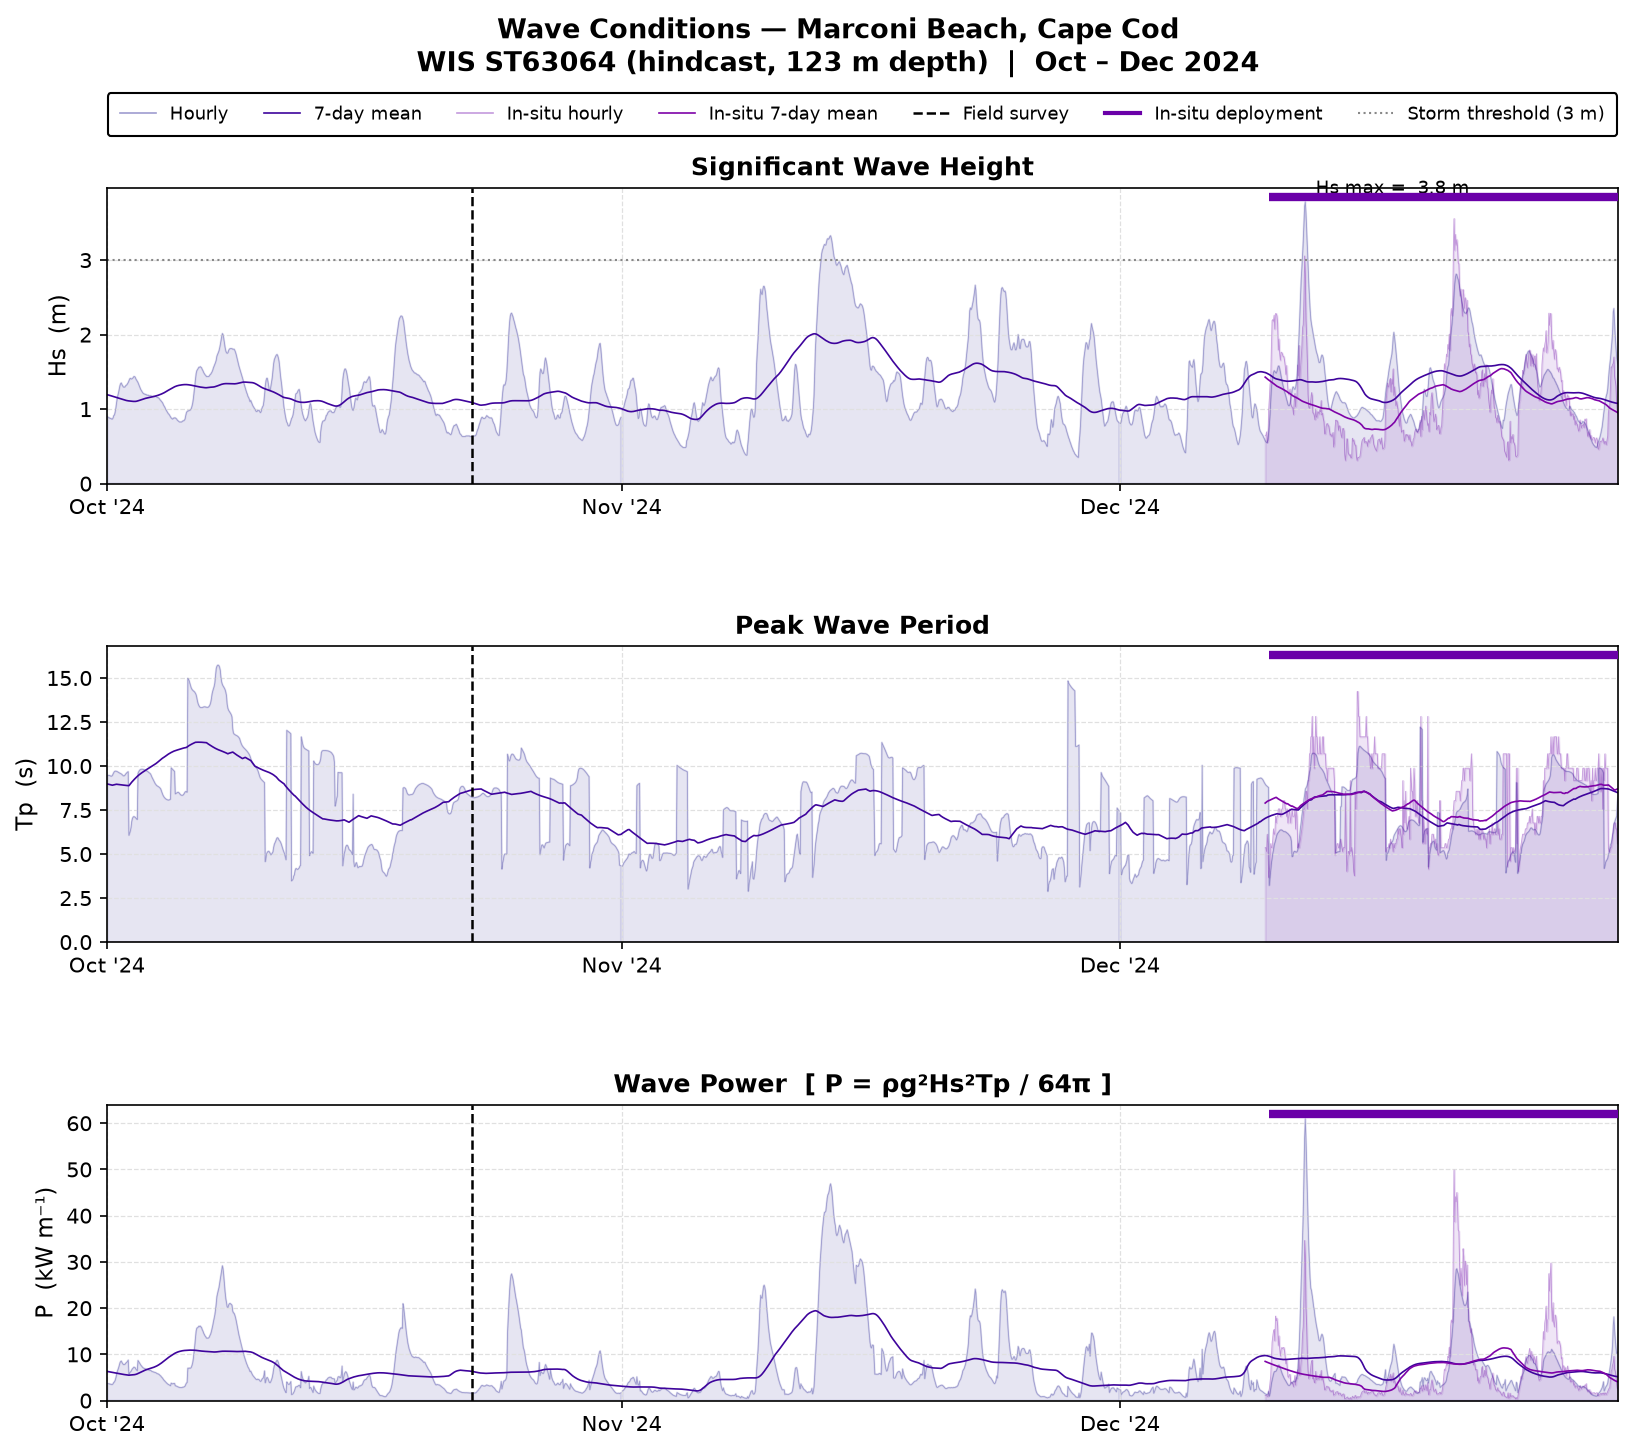

✓ Saved wave_timeseries_WIST63064.png


In [72]:
def plot_timeseries(df, source_label, color, mean_color, filename, start, end):
    df = df.resample("1h").mean()

    # 4 panels if insitu available (add water depth), else 3
    n_panels = 3 
    cols     = ["Hs", "Tp", "P_kW_m"][:n_panels]
    ylabels  = ["Hs  (m)", "Tp  (s)", "P  (kW m⁻¹)"][:n_panels]
    titles   = [
        "Significant Wave Height",
        "Peak Wave Period",
        "Wave Power  [ P = ρg²Hs²Tp / 64π ]"
    ][:n_panels]

    fig = plt.figure(figsize=(13, 3.5 * n_panels))
    fig.suptitle(
        f"Wave Conditions — Marconi Beach, Cape Cod\n{source_label}",
        fontsize=13, fontweight="bold", y=0.99
    )
    gs = GridSpec(n_panels, 1, figure=fig, hspace=0.55)

    # Build legend
    legend_handles = [
        Line2D([0], [0], color=color,                lw=0.8, alpha=0.4, label="Hourly"),
        Line2D([0], [0], color=mean_color,           lw=0.8,            label="7-day mean"),
    ]
    if insitu is not None:
        legend_handles += [
            Line2D([0], [0], color=PALETTE["insitu"],      lw=0.8, alpha=0.4, label="In-situ hourly"),
            Line2D([0], [0], color=PALETTE["insitu_mean"], lw=0.8,            label="In-situ 7-day mean"),
        ]
    legend_handles += [
        Line2D([0], [0], color=PALETTE["survey"], lw=1.2, ls="--", label="Field survey"),
        Line2D([0], [0], color=PALETTE["insitu"], lw=2,             label="In-situ deployment"),
        Line2D([0], [0], color="#888",            lw=1,  ls=":",    label="Storm threshold (3 m)"),
    ]

    for i, (col, ylabel, title) in enumerate(zip(cols, ylabels, titles)):
        ax = fig.add_subplot(gs[i])

        if col in df.columns:
            ax.fill_between(df.index, df[col], alpha=0.1, color=color)
            ax.plot(df.index, df[col],          color=color,      lw=0.4, alpha=0.3)
            ax.plot(df.index, rolling(df[col]), color=mean_color, lw=0.8)

        # Overlay in-situ data
        if insitu is not None and col in insitu.columns:
            ins = insitu.resample("1h").mean()
            ax.fill_between(ins.index, ins[col], alpha=0.1, color=PALETTE["insitu"])
            ax.plot(ins.index, ins[col],          color=PALETTE["insitu"],      lw=0.4, alpha=0.3)
            ax.plot(ins.index, rolling(ins[col]), color=PALETTE["insitu_mean"], lw=0.8)

        add_survey_lines(ax, SURVEY_DATES)

        ax.set_ylim(bottom=0)
        ax.set_xlim(pd.Timestamp(start), pd.Timestamp(end))
        style_xaxis(ax, START, END)

        add_insitu_bar(ax, INSITU_START, INSITU_END, start, end)

        if col == "Hs":
            ax.axhline(3.0, color="#888", lw=1, ls=":")
            idx_max = df[col].idxmax()
            ax.annotate(f"Hs max =  {df[col].max():.1f} m",
                        xy=(idx_max, df[col].max()),
                        xytext=(5, 4), textcoords="offset points",
                        fontsize=8.5, color='k')

        ax.set_ylabel(ylabel)
        ax.set_title(title)

        if i == 0:
            ax.legend(handles=legend_handles, loc="upper center", ncol=7, bbox_to_anchor=(0.5, 1.35), fontsize=8.5,frameon=True,framealpha=1,edgecolor="black",borderpad=0.7)

    fig.savefig(PLOT_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {filename}")

plot_timeseries(ndbc1, "NDBC 44020 (observed, 16.5 m depth)  |  Oct 2024 – Mar 2025",
                PALETTE["ndbc1"], PALETTE["ndbc_mean1"], "wave_timeseries_NDBC44020.png", START, END)


if wis is not None:
    plot_timeseries(wis, "WIS ST63064 (hindcast, 123 m depth)  |  Oct – Dec 2024",
                    PALETTE["wis"], PALETTE["wis_mean"], "wave_timeseries_WIST63064.png", START, "2024-12-31")

## 4. WIS NDBC 44013 for full time w. PUV

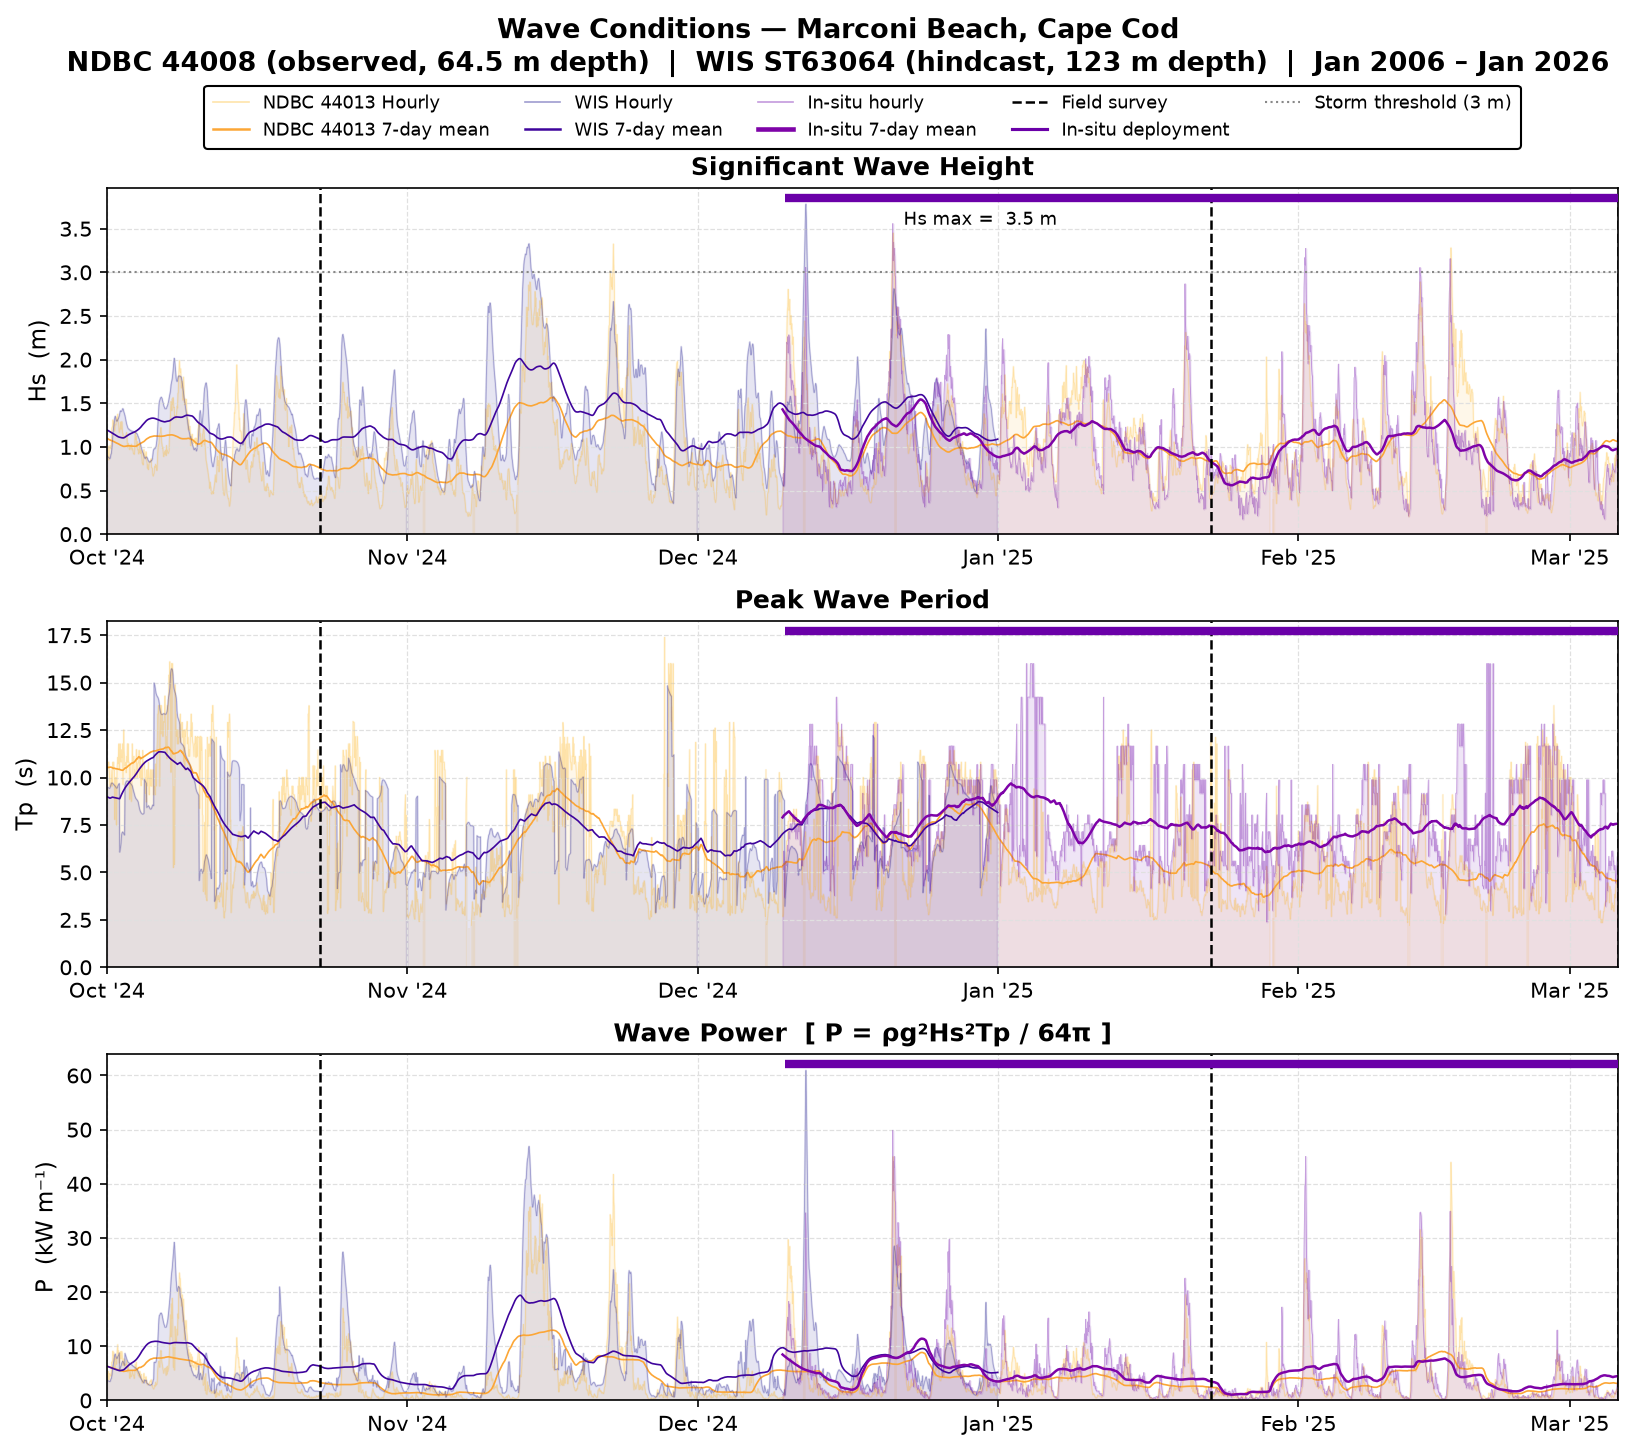

✓ Saved wave_timeseries_WISNDBC44020_2006-2026.png


In [73]:
def plot_2timeseries(df1, df2,source_label1, color1,color2, mean_color1,mean_color2, filename, start, end):
    df1 = df1.resample("1h").mean()
    df2 = df2.resample("1h").mean()
    # 4 panels if insitu available (add water depth), else 3
    n_panels = 3 
    cols     = ["Hs", "Tp", "P_kW_m"][:n_panels]
    ylabels  = ["Hs  (m)", "Tp  (s)", "P  (kW m⁻¹)"][:n_panels]
    titles   = [
        "Significant Wave Height",
        "Peak Wave Period",
        "Wave Power  [ P = ρg²Hs²Tp / 64π ]"
    ][:n_panels]

    fig = plt.figure(figsize=(13, 3.5 * n_panels))
    fig.suptitle(
        f"Wave Conditions — Marconi Beach, Cape Cod\n{source_label1}",
        fontsize=13, fontweight="bold", y=0.99
    )
    gs = GridSpec(n_panels, 1, figure=fig, hspace=0.25)

    # Build legend
    legend_handles = [
        Line2D([0], [0], color=color1,                lw=0.8, alpha=0.4, label="NDBC 44013 Hourly"),
        Line2D([0], [0], color=mean_color1,           lw=1.2,            label="NDBC 44013 7-day mean"),
        Line2D([0], [0], color=color2,                lw=0.8, alpha=0.4, label="WIS Hourly"),
        Line2D([0], [0], color=mean_color2,           lw=1.2,            label="WIS 7-day mean"),
    ]
    if insitu is not None:
        legend_handles += [
            Line2D([0], [0], color=PALETTE["insitu"],      lw=0.8, alpha=0.4, label="In-situ hourly"),
            Line2D([0], [0], color=PALETTE["insitu_mean"], lw=2.2,            label="In-situ 7-day mean"),
        ]
    legend_handles += [
        Line2D([0], [0], color=PALETTE["survey"], lw=1.2, ls="--", label="Field survey"),
        Line2D([0], [0], color=PALETTE["insitu"], lw=1.5,             label="In-situ deployment"),
        Line2D([0], [0], color="#888",            lw=1,  ls=":",    label="Storm threshold (3 m)"),
    ]

    for i, (col, ylabel, title) in enumerate(zip(cols, ylabels, titles)):
        ax = fig.add_subplot(gs[i])

        if col in df1.columns:
            ax.fill_between(df1.index, df1[col], alpha=0.1, color=color1)
            ax.plot(df1.index, df1[col],          color=color1,      lw=0.4, alpha=0.3)
            ax.plot(df1.index, rolling(df1[col]), color=mean_color1, lw=.8)

        if col in df1.columns:
            ax.fill_between(df2.index, df2[col], alpha=0.1, color=color2)
            ax.plot(df2.index, df2[col],          color=color2,      lw=0.4, alpha=0.3)
            ax.plot(df2.index, rolling(df2[col]), color=mean_color2, lw=.8) 

        # Overlay in-situ data
        if insitu is not None and col in insitu.columns:
            ins = insitu.resample("1h").mean()
            ax.fill_between(ins.index, ins[col], alpha=0.1, color=PALETTE["insitu"])
            ax.plot(ins.index, ins[col],          color=PALETTE["insitu"],      lw=0.4, alpha=0.3)
            ax.plot(ins.index, rolling(ins[col]), color=PALETTE["insitu_mean"], lw=1.2)

        add_survey_lines(ax, SURVEY_DATES)

        ax.set_ylim(bottom=0)
        ax.set_xlim(pd.Timestamp(start), pd.Timestamp(end))
        style_xaxis(ax,START,END)

        add_insitu_bar(ax, INSITU_START, INSITU_END, start, end)

        if col == "Hs":
            ax.axhline(3.0, color="#888", lw=1, ls=":")
            idx_max = df1[col].idxmax()
            ax.annotate(f"Hs max =  {df1[col].max():.1f} m",
                        xy=(idx_max, df1[col].max()),
                        xytext=(5, 4), textcoords="offset points",
                        fontsize=8.5, color='k')

        ax.set_ylabel(ylabel)
        ax.set_title(title)

        if i == 0:
            ax.legend(handles=legend_handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.32), fontsize=8.5,frameon=True,framealpha=1,edgecolor="black",borderpad=0.5)

    fig.savefig(PLOT_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {filename}")

plot_2timeseries(ndbc2, wis, "NDBC 44008 (observed, 64.5 m depth)  |  WIS ST63064 (hindcast, 123 m depth)  |  Jan 2006 – Jan 2026",
                PALETTE["ndbc1"], PALETTE["wis"], PALETTE["ndbc_mean1"],PALETTE["wis_mean"], "wave_timeseries_WISNDBC44020_2006-2026.png",START, END)



## 6. Box plot comparisons of WIS/NDBC and NDBC/PUV



  NDBC 44008     : 2506 rows | 2024-10-01 00:00:00 → 2024-10-18 09:30:00
  NDBC 44020     : 26208 rows | 2024-10-01 00:00:00 → 2025-03-31 23:50:00
  WIS ST63064    : 2205 rows | 2024-10-01 01:00:00 → 2024-12-31 23:00:00
  In-situ        : 2182 rows | 2024-12-09 18:00:00 → 2025-03-10 15:00:00


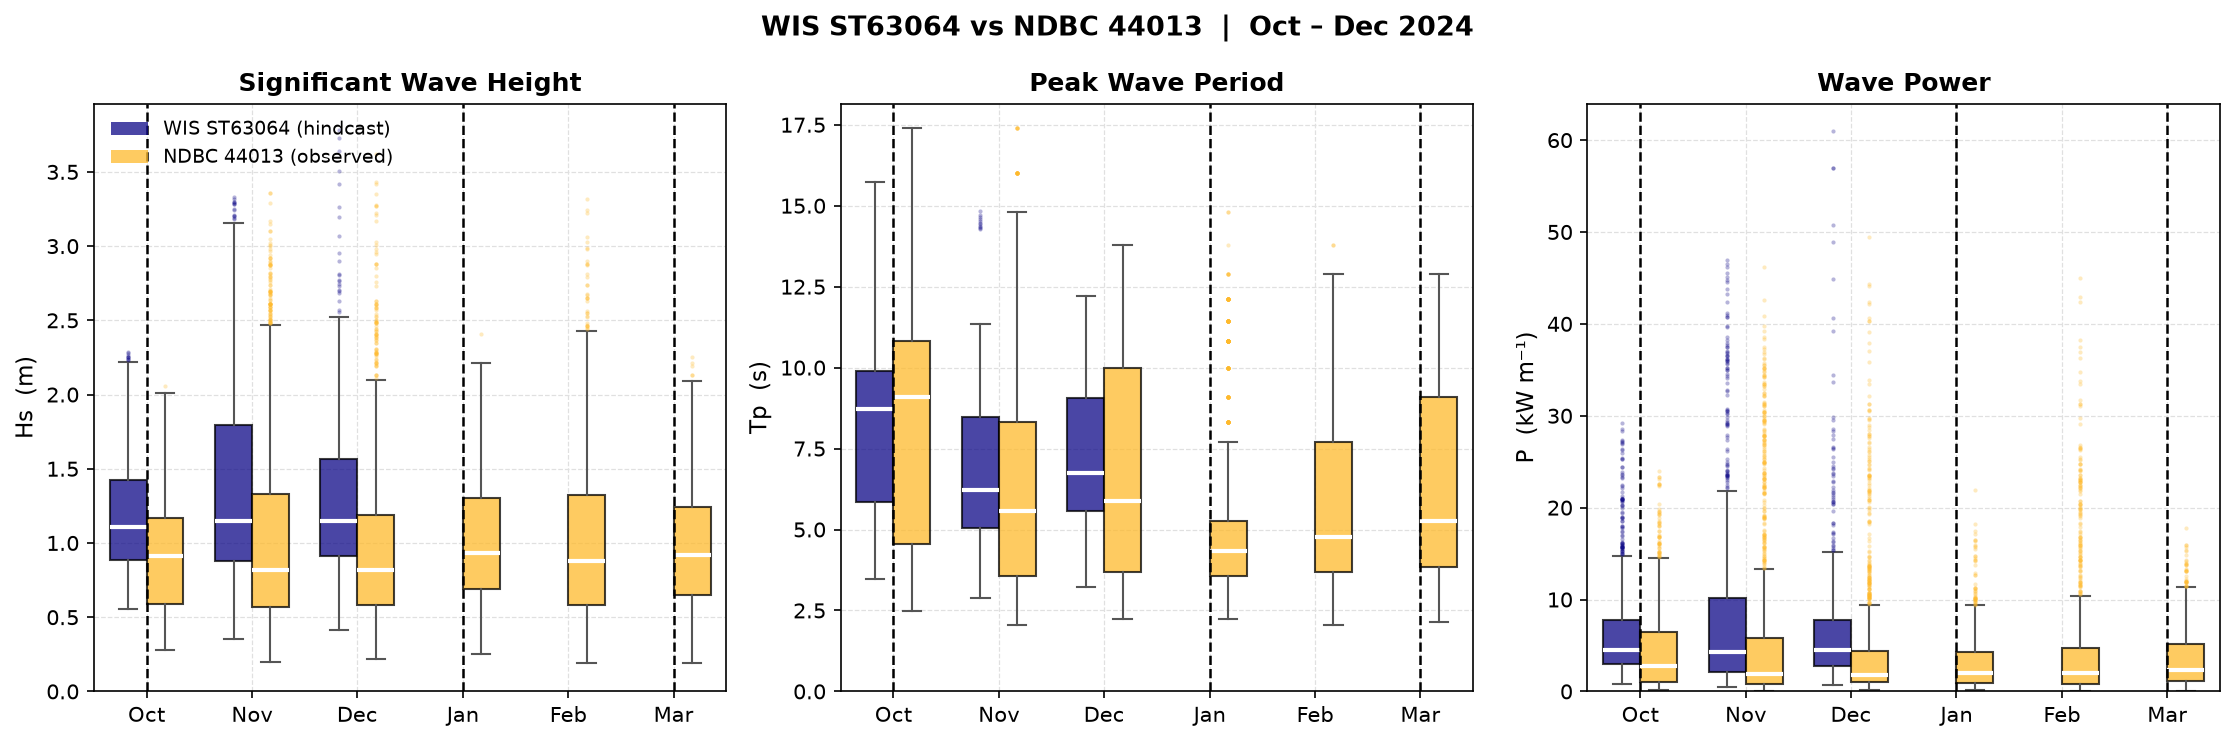

✓ Saved boxplots_WIS_vs_44013.png


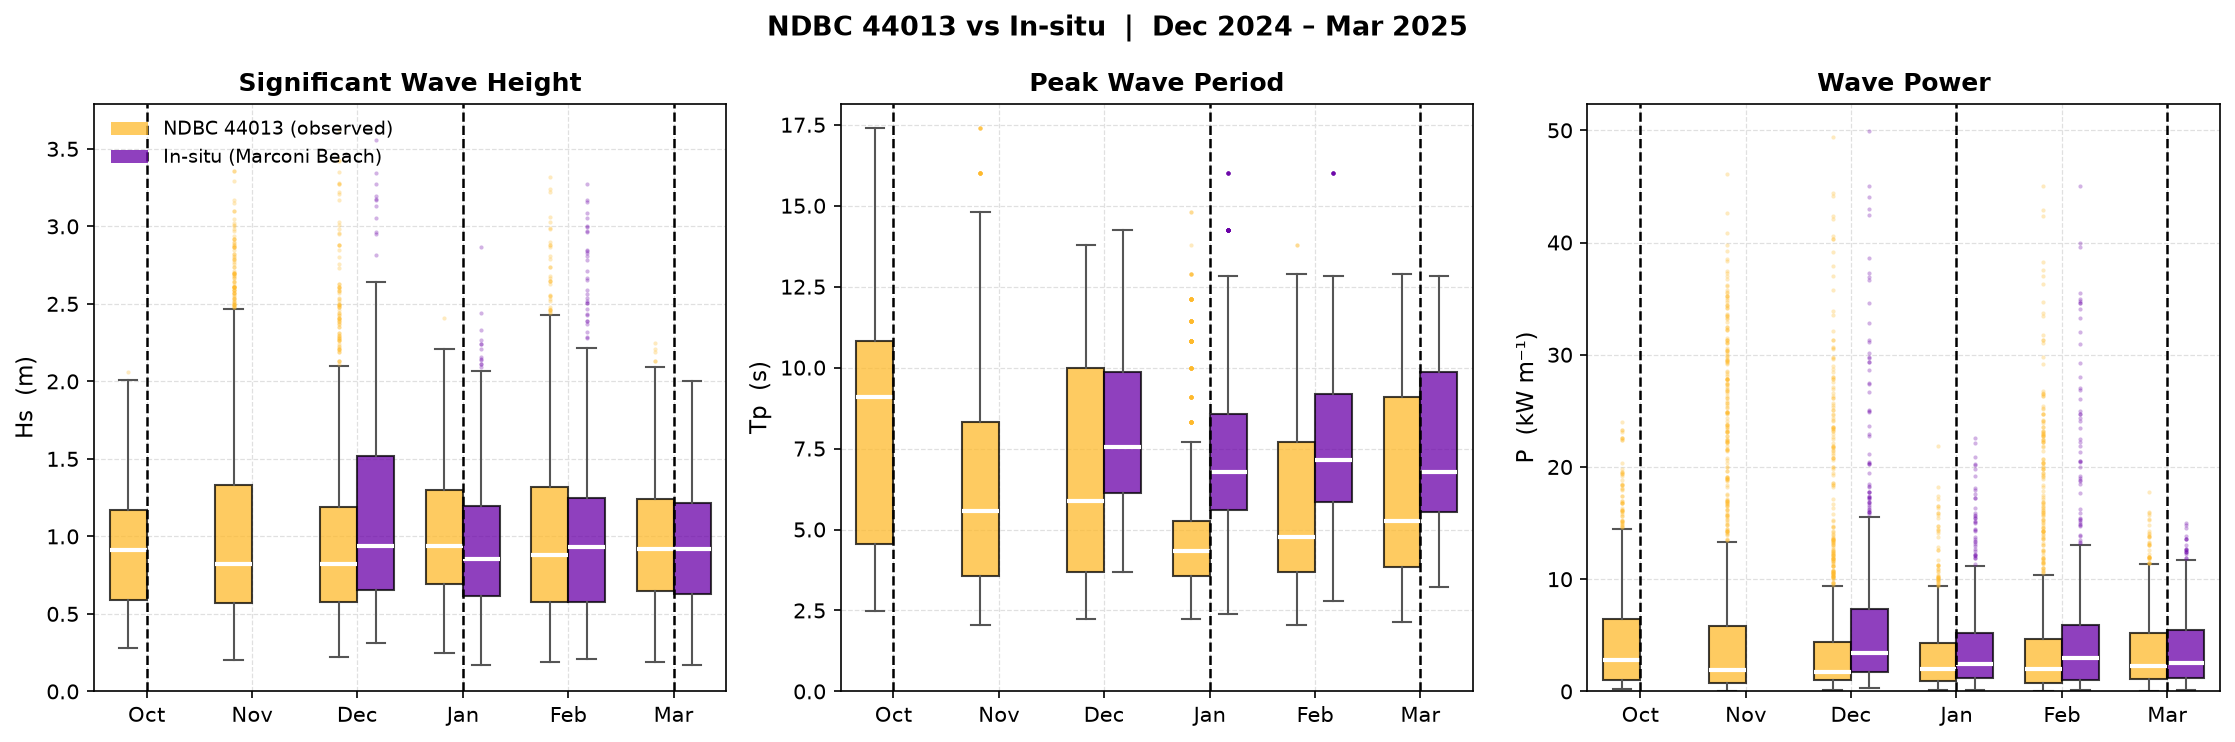

✓ Saved boxplots_44013_vs_insitu.png


In [74]:
# ── Load data from CSVs ───────────────────────────────────────────────────────
def load_ndbc_csv(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df.rename(columns={"WVHT": "Hs", "DPD": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Hs"]     = df["Hs"].where(df["Hs"] < 99.0)
    df["Tp"]     = df["Tp"].where(df["Tp"] < 99.0)
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    df["month"]  = df.index.to_period("M")
    return df

def load_wis_csv(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df.rename(columns={"waveHs": "Hs", "waveTp": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    df["month"]  = df.index.to_period("M")
    return df

def load_insitu_csv(path):
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.rename(columns={
        "time":        "datetime",
        "wh_4061":     "Hs",
        "wp_peak":     "Tp",
        "water_depth": "depth",
        "water_level": "water_level",
    })
    df = df.set_index("datetime")
    df = df.apply(pd.to_numeric, errors="coerce")
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    df["month"]  = df.index.to_period("M")
    return df

# Update paths as needed
NDBC_44008_FILE = OUT_DIR / f"NDBC_44008_{START[:7]}_to_{END[:7]}.csv"
NDBC_44020_FILE = OUT_DIR / f"NDBC_44020_{START[:7]}_to_{END[:7]}.csv"
NDBC_44013_FILE = OUT_DIR / f"NDBC_44013_{START[:7]}_to_{END[:7]}.csv"

WIS_FILE        = OUT_DIR / "WIS_ST63064_2024-10_to_2024-12.csv"
INSITU_FILE     = Path("sig1000_waves_ALL.csv")

ndbc_44008 = load_ndbc_csv(NDBC_44008_FILE) if NDBC_44008_FILE.exists() else None
ndbc_44020 = load_ndbc_csv(NDBC_44020_FILE) if NDBC_44020_FILE.exists() else None
ndbc_44013 = load_ndbc_csv(NDBC_44013_FILE) if NDBC_44013_FILE.exists() else None
wis        = load_wis_csv(WIS_FILE)          if WIS_FILE.exists()        else None
insitu     = load_insitu_csv(INSITU_FILE)    if INSITU_FILE.exists()     else None

for name, df in [("NDBC 44008", ndbc_44008), ("NDBC 44020", ndbc_44020),
                 ("WIS ST63064", wis), ("In-situ", insitu)]:
    if df is not None:
        print(f"  {name:15s}: {len(df)} rows | {df.index.min()} → {df.index.max()}")
    else:
        print(f"  {name:15s}: ⚠ file not found")


# ── Helper: side-by-side box plots for two datasets ───────────────────────────
def make_bp_kwargs(color, width):
    return dict(
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.75),
        whiskerprops=dict(color="#555"),
        capprops=dict(color="#555"),
        flierprops=dict(marker="o", markersize=2, alpha=0.3,
                        markerfacecolor=color, markeredgecolor="none"),
        widths=width,
    )

def plot_comparison_boxplots(df_a, df_b, label_a, label_b,
                              color_a, color_b, title, filename):
    """
    Side-by-side monthly box plots comparing two wave datasets.
    Both dataframes must have columns: Hs, Tp, P_kW_m and a 'month' Period column.
    """
    for df in [df_a, df_b]:
        if "month" not in df.columns:
            df["month"] = df.index.to_period("M")

    months       = sorted(set(df_a["month"].unique()) | set(df_b["month"].unique()))
    month_labels = [pd.Period(str(m), freq="M").to_timestamp().strftime("%b") for m in months]
    n_months     = len(months)
    x            = np.arange(1, n_months + 1)
    width        = 0.35

    bp_kwargs_a = make_bp_kwargs(color_a, width)
    bp_kwargs_b = make_bp_kwargs(color_b, width)

    def monthly_data(df, col):
        return [df[col][df["month"] == m].dropna().values for m in months]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, col, ylabel, panel_title in zip(
        axes,
        ["Hs", "Tp", "P_kW_m"],
        ["Hs  (m)", "Tp  (s)", "P  (kW m⁻¹)"],
        ["Significant Wave Height", "Peak Wave Period", "Wave Power"],
    ):
        pos_a = x - width / 2
        pos_b = x + width / 2

        ax.boxplot(monthly_data(df_a, col), positions=pos_a, **bp_kwargs_a)
        ax.boxplot(monthly_data(df_b, col), positions=pos_b, **bp_kwargs_b)

        ax.set_xticks(x)
        ax.set_xticklabels(month_labels)
        ax.set_xlim(0.5, n_months + 0.5)
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title, fontweight="bold")
        ax.set_ylim(bottom=0)
        ax.tick_params(axis="x", rotation=0)
        ax.grid(axis="y", color="#e0e0e0", linewidth=0.6, linestyle="--")

        for d in SURVEY_DATES:
            p = pd.Timestamp(d).to_period("M")
            if p in months:
                xi = months.index(p) + 1
                ax.axvline(xi, color=PALETTE["survey"], lw=1.2, ls="--", zorder=3)

        if ax == axes[0]:
            from matplotlib.patches import Patch
            ax.legend(handles=[
                Patch(facecolor=color_a, alpha=0.75, label=label_a),
                Patch(facecolor=color_b, alpha=0.75, label=label_b),
            ], fontsize=9, loc="upper left")

    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {filename}")


# ── Figure A: WIS ST63064 vs NDBC 44013 ──────────────────────────────────────
if wis is not None and ndbc_44013 is not None:
    plot_comparison_boxplots(
        df_a=wis,
        df_b=ndbc_44013,
        label_a="WIS ST63064 (hindcast)",
        label_b="NDBC 44013 (observed)",
        color_a=PALETTE["wis"],
        color_b=PALETTE["ndbc1"],
        title="WIS ST63064 vs NDBC 44013  |  Oct – Dec 2024",
        filename="boxplots_WIS_vs_44013.png",
    )
else:
    print("⚠ WIS or NDBC 44013 data not available.")


# ── Figure B: NDBC 44013 vs In-situ ──────────────────────────────────────────
if ndbc_44013 is not None and insitu is not None:
    plot_comparison_boxplots(
        df_a=ndbc_44013,
        df_b=insitu,
        label_a="NDBC 44013 (observed)",
        label_b="In-situ (Marconi Beach)",
        color_a=PALETTE["ndbc1"],
        color_b=PALETTE["insitu"],
        title="NDBC 44013 vs In-situ  |  Dec 2024 – Mar 2025",
        filename="boxplots_44013_vs_insitu.png",
    )
else:
    print("⚠ NDBC 44013 or in-situ data not available.")